In [1]:
# for interactive plots:
# %matplotlib widget

# for static plots:
%matplotlib inline

# Longitudinal plane, collective effects and monitoring beam stats

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import xtrack as xt
import xwakes as xw

### Import machine and twiss

In [3]:
env = xt.load('./pimm.json')
env.vars.load('./pimm_strengths.json')

line = env.ring
line.configure_bend_model(num_multipole_kicks=5)
line.set_particle_ref('proton', kinetic_energy0=100e6)

tw4d = line.twiss(method='4d')

Loading line from dict:   0%|          | 0/86 [00:00<?, ?it/s]

In [4]:
# Insert aperture limitation to see losses
line.append('aperture', xt.LimitRect(min_x=-0.05, max_x=0.05))

### Switch on the RF

In [5]:
line['vrf'] = 10e3            # V
line['frf'] = 1 / tw4d.t_rev0 # h=1

In [6]:
# 6D twiss
tw = line.twiss6d()
tw.qs

np.float64(0.0021295285732079172)

### Inspect longitudinal phase space

In [7]:
# Build a set of particles with different momenta
p = line.build_particles(delta=np.linspace(-1e-2, 1e-2, 41))

In [8]:
# Track (logging turn by turn data)
line.track(p, num_turns=2000, turn_by_turn_monitor=True, with_progress=True)

Tracking:   0%|          | 0/2000 [00:00<?, ?it/s]

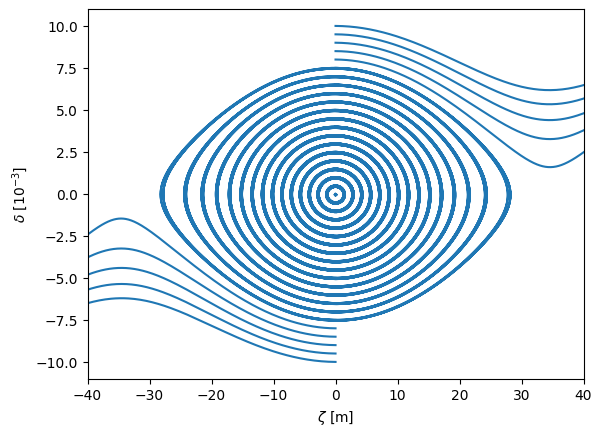

In [9]:
# Plot turn-by-turn data in the longitudinal plane
mon = line.record_last_track

plt.figure()
plt.plot(mon.zeta.T, mon.delta.T*1e3, color='C0');
plt.xlim(-40, 40)
plt.xlabel(r'$\zeta$ [m]')
plt.ylabel(r'$\delta$ [10$^{-3}$]')
plt.show()

## Install transverse wakefields

For more info on available collective effects, see the corresponding [section in the User's guide](https://xsuite.readthedocs.io/en/latest/collective.html).

In [10]:
wf = xw.WakeResonator(kind='dipolar_x',
                      r=100e6, # Shunt impedance [Ohm/m]
                      f_r=1.3e6,
                      q=1.)
wf.configure_for_tracking(zeta_range=(-20, 20), num_slices=20)                      

In [11]:
# Install wakefield in the Xsuite ring
line.append('wf', obj=wf)

### Install a beam stats monitor
Instead of logging particle-by-particle data, we will log statistical moments. For more information on monitors see corresponding [section in the User's guide](https://xsuite.readthedocs.io/en/latest/track.html#beam-statistics-monitor).

In [12]:
monitor = xt.BeamStatsMonitor(
    start_at_turn=0,
    stop_at_turn=1000,
    stats=["num_particles", "mean_x", "sigma_x"],
)
line.append('beam_stats_mon', obj=monitor)

### Generate a bunch matched to the bucket and to the optics

For more info on generation of particle distributions see corresponding [section in the User's guide](https://xsuite.readthedocs.io/en/latest/particlesmanip.html).

In [13]:
%%capture
bunch = line.xpart.generate_matched_gaussian_bunch(
    num_particles=1000,
    total_intensity_particles=1e11,
    nemitt_x=2e-6, nemitt_y=2e-6, sigma_z=10.)

# Initial kick of 1 mm
bunch.x += 1e-3

# Keep initial state
bunch0 = bunch.copy() 

### Simulate 1000 turns

In [14]:
line.track(bunch, num_turns=1000, with_progress=10)

Tracking:   0%|          | 0/1000 [00:00<?, ?it/s]

### Plot intensity and centroid motion

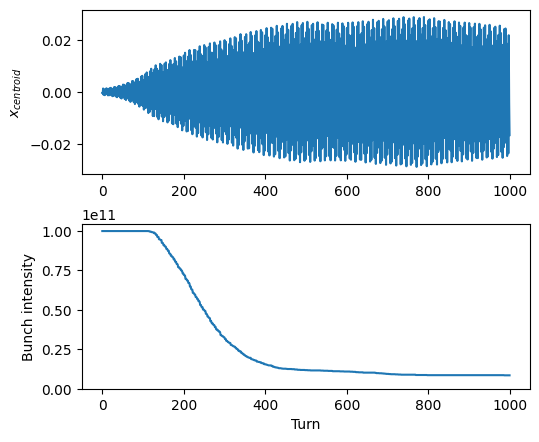

In [15]:
x_mean = monitor.mean_x.copy()
intensity = monitor.num_particles.copy()

plt.figure()
ax1 = plt.subplot(2,1,1)
plt.ylabel(r'$x_{centroid}$')
plt.plot(x_mean)
ax2 = plt.subplot(2,1,2, sharex=ax1)
plt.plot(intensity)
plt.ylim(bottom=0)
plt.ylabel('Bunch intensity')
plt.xlabel('Turn')

plt.subplots_adjust(left=0.2, hspace=0.3, top=0.9)

### Adjust the sextupoles to change the chromaticity

In [16]:
%%capture
opt = line.match(
    solve=False,
    method='4d',
    vary=xt.VaryList(['ksf', 'ksd'], step=1e-3),
    targets=xt.TargetSet(dqx=-4., dqy=-4., tol=1e-3, tag="chrom")
)
opt.solve()

In [17]:
opt.vary_status()
opt.target_status()

Vary status:                 
id state tag met name lower_limit   current_val upper_limit val_at_iter_0          step        weight
0  ON        OK  ksf  None             -2.84572 None             0.583502         0.001             1
1  ON        OK  ksd  None              2.51692 None            -0.780772         0.001             1
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
Target status:               nalty = 4.8296e-06              
id state tag   tol_met       residue   current_val    target_val description                       
0  ON    chrom    True  -4.82956e-06            -4            -4 'dqx', val=-4, tol=0.001, weight=1
1  ON    chrom    True  -1.19904e-09            -4            -4 'dqy', val=-4, tol=0.001, weight=1


### Repeat the simulation

In [18]:
# Clear monitor content
monitor.start_new_frame(start_at_turn=0)

In [19]:
bunch = bunch0.copy()
bunch.x += 1e-3

In [20]:
line.track(bunch, num_turns=1000, with_progress=10)

Tracking:   0%|          | 0/1000 [00:00<?, ?it/s]

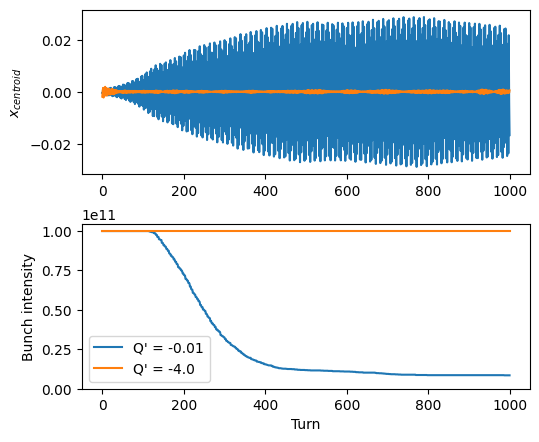

In [21]:
# Plot logged data
x_mean_high_chroma = monitor.mean_x.copy()
intensity_high_chroma = monitor.num_particles.copy()

plt.figure()
ax1 = plt.subplot(2,1,1)
plt.ylabel(r'$x_{centroid}$')
plt.plot(x_mean, label="Q' = -0.01")
plt.plot(x_mean_high_chroma, label="Q' = -4.0")
ax2 = plt.subplot(2,1,2, sharex=ax1)
plt.plot(intensity, label="Q' = -0.01")
plt.plot(intensity_high_chroma, label="Q' = -4.0")
plt.ylim(bottom=0)
plt.ylabel('Bunch intensity')
plt.xlabel('Turn')
plt.legend()

plt.subplots_adjust(left=0.2, hspace=0.3, top=0.9)